# HASP · Reading a neighbourhood from data
### Leeds Digital Festival: hands-on workshop

You've seen what HASP is. Now let's look at some neighbourhood-level data.

Everything here is **real, open data at LSOA level** (a Lower-layer Super Output Area is a
neighbourhood of ~1,500 people). We focus on **Leeds** by default, one switch in **S1** runs all of
**West Yorkshire** instead.

| Dataset | What it tells us | Direction (as used here) |
|---|---|---|
| **PPFI** (HASP) | priority for food insecurity | decile **1 = highest priority** (worst) |
| **IMD 2025** | overall deprivation | decile **1 = most deprived** |
| **Which? Insulation Index** | homes most in need of insulation | decile **1 = greatest need** † |
| **Zoopla / WhenFresh** | median weekly rent, by year | £ per week |

**All three indices are lined up the same way: decile 1 = worst.**

> † The insulation index is *published* the other way round (its decile 1 = **lowest** need).
> `load_area()` flips it on load so it matches the other two. Different providers pick different
> directions, always check.

### How this notebook is laid out


| ID | Section | What happens |
|---|---|---|
| **S1–S4** | Setup | config, packages, and the functions we reuse |
| **A** | Meet the area | load the data, check how complete it is |
| **B** | First map | where food priority is worst |
| **C** | Agreement | do the three indices point at the same places? |
| **D** | Stacked burdens | the short list you'd act on ← *the takeaway* |
| **E** | kepler.gl | make a map that argues for something |
| **F** | Rent over time | a different shape of geospatial data |
| **H** | Bring your own data | load *your* dataset and map it |

**Cells marked ✏️ are yours to change.** Everything else you can just run.

> **Start:** `Runtime → Run all`, then read from the top. First run takes ~1 minute.

---
## Setup

Four cells. **S1 is the only one you'd normally change**, the rest is code you can skip.

In [1]:
# ── S1 ────────────────────────────────────────────────────────────────
# ✏️ THE ONLY SETTINGS YOU NEED TO TOUCH
# ──────────────────────────────────────────────────────────────────────

LEEDS_ONLY = True    # True = Leeds only · False = all of West Yorkshire
WORST      = 2       # "high need" = worst fifth of an index (deciles 1-2)
BASEMAP    = True    # draw a street/terrain background behind the maps

# ──────────────────────────────────────────────────────────────────────
DATA = "data"        # folder holding the data files (leave as-is on Colab)

In [2]:
# ── S2 ── packages, data files, and (on Colab) fetching the data ──────
# Plumbing. Nothing to read here.

%pip install -q h3 contextily

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import h3
import contextily as cx
from matplotlib.colors import ListedColormap
from IPython.display import display

# On Colab there's no data/ folder until we fetch it from GitHub.
if not os.path.exists(DATA):
    if not os.path.isdir("/content/hasp"):
        !git clone --depth 1 https://github.com/Leeds-HASP/digital-festival-2026.git /content/hasp
    os.chdir("/content/hasp")
print("working folder:", os.getcwd(), "· data found:", os.path.exists(DATA))

# data files
BOUNDARIES = "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5.gpkg"
PPFI       = "hasp_ppfi_v2.1.csv"
IMD        = "imd_2025.csv"
INSULATION = "which_insulation_index.csv"
RENT       = "zoopla_rent.csv"
LSOA_LOOKUP, REGION_LOOKUP = "lsoa_lookup.csv", "region_lookup.csv"

# derived from S1
DISTRICTS = ["Leeds"] if LEEDS_ONLY else ["Leeds", "Bradford", "Kirklees", "Calderdale", "Wakefield"]
AREA_NAME = "Leeds" if LEEDS_ONLY else "West Yorkshire"

# HASP house palette: dark = worse, light = better
PALETTE      = ["#08306b", "#08519c", "#2171b5", "#4292c6", "#6baed6",
                "#9ecae1", "#c6dbef", "#deebf7", "#f7fbff", "#ffffff"]
HASP_BLUES   = ListedColormap(PALETTE[::-1])   # light -> dark (higher value = darker)
HASP_BLUES_R = ListedColormap(PALETTE)         # dark -> light (deciles: 1 = worst = darkest)

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"ready · area = {AREA_NAME}")

Note: you may need to restart the kernel to use updated packages.
working folder: /Users/xgrh928/Codes/digitalfestival_demo · data found: True
ready · area = Leeds


### S3 & S4: the functions we reuse

All the fiddly work lives in these two cells, behind plain-English names. **You don't need to read
them**, just know what they're called:

**S3 · getting data**
- `load_area()`: every neighbourhood in your area, with all three indices joined
- `high_need(decile)`: True for the worst fifth (deciles 1–2)
- `describe_area(area)`: how many neighbourhoods, how complete each dataset is

**S4 · drawing things**
- `show_map(area, column, title)`: the standard map
- `show_map_h3(area, column, title, res=9)`: the same thing on H3 hexagons
- `plot_agreement_heatmap(area, a, b)` · `plot_bivariate_map(area, a, b)`: section C
- `add_burden_count(area)` · `show_top_neighbourhoods(area)`: section D
- `join_my_data(...)` · `upload_csv()`: section H

In [3]:
# ── S3 ── getting the data ready ──────────────────────────────────────

def load_area():
    """Every LSOA in the chosen area, with PPFI (+ its 7 domains), IMD and insulation joined."""
    geo = gpd.read_file(f"{DATA}/{BOUNDARIES}")
    geo["district"] = geo["LSOA21NM"].str.rsplit(" ", n=1).str[0]
    area = (geo[geo["district"].isin(DISTRICTS)]
              .loc[:, ["LSOA21CD", "LSOA21NM", "district", "geometry"]]
              .rename(columns={"LSOA21CD": "lsoa", "LSOA21NM": "name"})
              .to_crs(4326)
              .reset_index(drop=True))

    def join_index(csv, code_col, value_col, new_name):
        t = pd.read_csv(f"{DATA}/{csv}")
        t.columns = [c.strip().lstrip("﻿") for c in t.columns]   # some files carry a BOM
        return (t[[code_col, value_col]]
                  .rename(columns={code_col: "lsoa", value_col: new_name})
                  .drop_duplicates("lsoa"))

    # PPFI: England only. Combined priority decile + the 7 domain deciles behind it.
    PPFI_DOMAINS = {
        "pp_dec_domain_supermarket_proximity":     "d_supermarket_proximity",
        "pp_dec_domain_supermarket_accessibility": "d_supermarket_access",
        "pp_dec_domain_ecommerce_access":          "d_online_access",
        "pp_dec_domain_nonsupermarket_proximity":  "d_nonsupermarket",
        "pp_dec_domain_socio_demographic":         "d_socioeconomic",
        "pp_dec_domain_food_for_families":         "d_family_support",
        "pp_dec_domain_fuel_poverty":              "d_fuel_poverty",
    }
    ppfi = pd.read_csv(f"{DATA}/{PPFI}")
    ppfi = (ppfi[ppfi["country"] == "E"][["lsoa21cd", "pp_dec_combined", *PPFI_DOMAINS]]
              .rename(columns={"lsoa21cd": "lsoa", "pp_dec_combined": "food_decile", **PPFI_DOMAINS}))

    out = (area.merge(ppfi, on="lsoa", how="left")
               .merge(join_index(IMD, "lsoa_code", "imd_decile", "imd_decile"), on="lsoa", how="left")
               .merge(join_index(INSULATION, "Geo_code", "Combined_deciles", "insulation_decile"),
                      on="lsoa", how="left"))

    # Insulation is published the other way round: flip so decile 1 = worst everywhere.
    out["insulation_decile"] = 11 - out["insulation_decile"]
    return out


def high_need(decile_series):
    """True where a neighbourhood is in the worst fifth (deciles 1-WORST) of an index."""
    return decile_series <= WORST


def describe_area(area):
    """Print how many neighbourhoods we have and how complete each dataset is."""
    print(f"{AREA_NAME}: {len(area):,} neighbourhoods\n")
    for col in ["food_decile", "imd_decile", "insulation_decile"]:
        print(f"  {col:20s} {area[col].notna().mean():.0%} complete")
    area["high_food_need"] = high_need(area["food_decile"])
    summary = (area.groupby("district")
                   .agg(neighbourhoods=("lsoa", "size"),
                        share_high_food_need=("high_food_need", "mean"))
                   .round(2))
    print()
    display(summary)


def load_rent():
    """Median weekly rent per neighbourhood per year (Zoopla/WhenFresh), with region labels."""
    rent = pd.read_csv(f"{DATA}/{RENT}")
    lsoa_ref   = pd.read_csv(f"{DATA}/{LSOA_LOOKUP}")
    region_ref = pd.read_csv(f"{DATA}/{REGION_LOOKUP}")
    return (rent.merge(lsoa_ref, left_on="lsoa_code", right_on="LSOA21CD", how="inner")
                .merge(region_ref, on="LAD25CD", how="inner"))


def join_my_data(csv_path, code_column, value_column, area=None):
    """Join YOUR csv (one row per LSOA) onto the map. Returns something show_map() can draw."""
    base = (area if area is not None else globals()["area"])
    base = base[["lsoa", "name", "district", "geometry"]].copy()
    t = pd.read_csv(csv_path)
    t.columns = [c.strip().lstrip("﻿") for c in t.columns]
    t = (t[[code_column, value_column]]
           .rename(columns={code_column: "lsoa", value_column: "my_value"})
           .drop_duplicates("lsoa"))
    out = base.merge(t, on="lsoa", how="left")
    print(f"matched {out['my_value'].notna().sum():,} of {len(out):,} neighbourhoods")
    if out["my_value"].notna().sum() == 0:
        print("  -> nothing matched. Is 'code_column' the LSOA 2021 code (like E01011XXX)?")
    return out


def upload_csv():
    """Colab only: opens a file picker and returns the uploaded filename."""
    from google.colab import files
    uploaded = files.upload()
    return list(uploaded)[0]

print("S3 ready: load_area · high_need · describe_area · load_rent · join_my_data · upload_csv")

S3 ready: load_area · high_need · describe_area · load_rent · join_my_data · upload_csv


In [18]:
# ── S4 ── drawing things ──────────────────────────────────────────────

def show_map(gdf, column, title, cmap=HASP_BLUES_R, basemap=None):
    """The standard map. Dark = worse. Set basemap=False for a plain white background."""
    use_bg = BASEMAP if basemap is None else basemap
    m = gdf.to_crs(3857) if use_bg else gdf          # web tiles need this projection
    fig, ax = plt.subplots(figsize=(8, 8))
    m.plot(column=column, cmap=cmap, ax=ax, legend=True,
           alpha=0.75 if use_bg else 1.0,
           edgecolor="#222222", linewidth=0.15,
           missing_kwds={"color": "#f0f0f0", "edgecolor": "#222222",
                         "linewidth": 0.15, "label": "no data"},
           legend_kwds={"shrink": 0.55})
    if use_bg:
        try:
            cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas, attribution_size=5)
        except Exception as e:
            print(f"(background map unavailable: {type(e).__name__}, the map itself is fine)")
    ax.set_title(title, fontsize=12, weight="bold", loc="left", pad=10)
    ax.set_axis_off()
    fig.tight_layout(); plt.show()


def show_agreement_stats(area, indices=("food_decile", "imd_decile", "insulation_decile")):
    """How much do the indices agree? Correlation table + overlap percentages."""
    print("Spearman rank correlation (1.0 = identical ordering)\n")
    display(area[list(indices)].corr(method="spearman").round(2))
    worst_food = area[high_need(area["food_decile"])]
    print(f"\n{len(worst_food)} neighbourhoods are high food-need. Of those:")
    print(f"  {high_need(worst_food['imd_decile']).mean():.0%} are also high deprivation")
    print(f"  {high_need(worst_food['insulation_decile']).mean():.0%} are also high insulation need")


def plot_agreement_heatmap(area, var_1, var_2):
    """10x10 grid: how many neighbourhoods fall in each combination of two deciles."""
    grid = (pd.crosstab(area[var_1], area[var_2])
              .reindex(index=range(1, 11), columns=range(1, 11), fill_value=0))
    fig, ax = plt.subplots(figsize=(5.4, 4.9))
    sns.heatmap(grid, ax=ax, cmap="Blues", annot=True, fmt="d",
                linewidths=0.3, linecolor="white",
                cbar_kws={"shrink": 0.85, "label": "neighbourhoods"})
    ax.invert_yaxis()                                  # keep decile 1 at the bottom
    ax.set(xlabel=var_2, ylabel=var_1, title=f"Neighbourhoods by {var_1} × {var_2}")
    plt.tight_layout(); plt.show()


BIVARIATE_KEY = ["#e8e8e8", "#e4acac", "#c85a5a",
                 "#b0d5df", "#ad9ea5", "#985356",
                 "#64acbe", "#627f8c", "#574249"]

def plot_bivariate_map(area, var_1, var_2, basemap=None):
    """Two indices on one map: teal = var_1 only, pink = var_2 only, dark = worst on both."""
    def tercile(s): return pd.qcut(s.rank(method="first"), 3, labels=[0, 1, 2]).astype(int)
    a3, b3 = tercile(11 - area[var_1]), tercile(11 - area[var_2])
    colours = (a3 * 3 + b3).values

    use_bg = BASEMAP if basemap is None else basemap
    m = area.to_crs(3857) if use_bg else area
    fig, ax = plt.subplots(figsize=(8, 8))
    m.plot(color=[BIVARIATE_KEY[c] for c in colours], ax=ax,
           alpha=0.8 if use_bg else 1.0, edgecolor="#333333", linewidth=0.1)
    if use_bg:
        try:
            cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas, attribution_size=5)
        except Exception:
            pass
    ax.set_title(f"{var_1} × {var_2} in {AREA_NAME}", fontsize=12, weight="bold", loc="left")
    ax.set_axis_off()

    key = fig.add_axes([0.13, 0.13, 0.15, 0.15])
    key.imshow(np.arange(9).reshape(3, 3), cmap=ListedColormap(BIVARIATE_KEY), origin="lower")
    key.set_xlabel(f"{var_2} →", fontsize=7); key.set_ylabel(f"{var_1} →", fontsize=7)
    key.set_xticks([]); key.set_yticks([])
    plt.show()


def add_burden_count(area):
    """Count how many of the three problems each neighbourhood is in the worst fifth for (0-3)."""
    area["burden_count"] = (high_need(area["food_decile"]).astype(int)
                          + high_need(area["imd_decile"]).astype(int)
                          + high_need(area["insulation_decile"]).astype(int))
    area["mean_decile"] = area[["food_decile", "imd_decile", "insulation_decile"]].mean(axis=1)
    return area


def show_top_neighbourhoods(area, n=10):
    """The short list: most burdens first, worst average decile as the tie-break."""
    print(f"{AREA_NAME} neighbourhoods by number of stacked burdens:")
    display(area["burden_count"].value_counts().sort_index().rename("neighbourhoods"))
    top = area.sort_values(["burden_count", "mean_decile"], ascending=[False, True]).head(n)
    print(f"\nTop {n} highest-need neighbourhoods in {AREA_NAME}:")
    display(top[["name", "district", "food_decile", "imd_decile",
                 "insulation_decile", "burden_count"]].reset_index(drop=True))
    return top




def plot_rent_trend(rent, by=None):
    """Median weekly rent over time, nationally, or split by a column (e.g. region)."""
    plt.figure(figsize=(9, 5))
    if by is None:
        rent.groupby("closing_year")["median_rent"].median().plot(marker="o", color="#08519c")
        plt.title("Median weekly rent, all areas")
    else:
        sns.lineplot(data=rent, x="closing_year", y="median_rent",
                     hue=by, marker="o", errorbar=None)
        plt.legend(title=by, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
        plt.title(f"Median weekly rent by {by}")
    plt.xlabel("Year"); plt.ylabel("Median weekly rent (£)")
    plt.tight_layout(); plt.show()


def export_for_kepler(area, stem="area_need"):
    """Write a GeoJSON (+ plain CSV) and, on Colab, download the GeoJSON."""
    area.to_file(f"{stem}.geojson", driver="GeoJSON")
    area.drop(columns="geometry").to_csv(f"{stem}.csv", index=False)
    print(f"wrote {stem}.geojson and {stem}.csv")
    try:
        from google.colab import files
        files.download(f"{stem}.geojson")
    except Exception:
        print("(not on Colab, find the files in the folder on the left)")


def convert_lsoa_to_h3shape(gdf_lsoa_inp, res=10):
    gdf_lsoa = gdf_lsoa_inp.copy()
    intial_crs = gdf_lsoa.crs
    if intial_crs != "EPSG:4326":
        gdf_lsoa = gdf_lsoa.to_crs("EPSG:4326")
        print(f"Converted CRS from {intial_crs} to EPSG:4326 for H3 processing.")

    h3shapes = {}
    h3cells = {}
    empty_shapes = 0
    for i, row in gdf_lsoa.iterrows():
        geom = row.geometry
        try:
            # Using h3.geo_to_h3shape requires h3-py >= 4.0
            h3shape = h3.geo_to_h3shape(geom)
            cells = h3.h3shape_to_cells(h3shape, res=res)
            refined_h3shape = h3.cells_to_h3shape(cells)

            if len(cells) == 0:
                empty_shapes += 1
                # If shape is empty, we keep the key but value might be empty/invalid geometry
                # Depending on library version this might need handling.
                # For plotting, an empty geometry usually just doesn't show.

            h3shapes[row['lsoa']] = refined_h3shape
            h3cells[row['lsoa']] = cells
        except Exception as e:
            print(f"Error converting LSOA {row['lsoa']}: {e}")
            empty_shapes += 1

    h3shape_gdf = gpd.GeoDataFrame({'lsoa': list(h3shapes.keys()),
                                    'h3_cells': list(h3cells.values()),
                                    'geometry': list(h3shapes.values())})

    # Drop original geometry and merge new H3 geometry
    gdf_lsoa_dropped = gdf_lsoa.drop(columns=['geometry'])
    merged_df = gdf_lsoa_dropped.merge(h3shape_gdf, on='lsoa')

    # Re-create GeoDataFrame with new geometry
    merged_gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs="EPSG:4326")

    # Project back to original CRS
    if intial_crs is not None:
        merged_gdf = merged_gdf.to_crs(intial_crs)

    if empty_shapes > 0:
        print(f"Warning: {empty_shapes} empty H3 shapes found out of {len(gdf_lsoa)} LSOAs at resolution {res}.")
    else:
        print(f"Success: no empty H3 shapes. Converted {len(gdf_lsoa)} LSOAs to H3 shapes at resolution {res}.")
    return merged_gdf


def show_map_h3(gdf, column, title, cmap=HASP_BLUES_R, res=10):
    """Static HASP-styled choropleth for H3 shapes: blue ramp, thin borders, clean layout.
    Default cmap suits deciles (1 = worst is darkest); pass HASP_BLUES for 'more = darker' fields."""
    fig, ax = plt.subplots(figsize=(8,8))
    gdf_h3 = convert_lsoa_to_h3shape(gdf, res=res)
    gdf_h3.plot(column=column, cmap=cmap, ax=ax, legend=True,
            edgecolor="#222222", linewidth=0.15,
            missing_kwds={"color": "#f0f0f0", "edgecolor": "#222222",
                        "linewidth": 0.15, "label": "no data"},
            legend_kwds={"shrink": 0.55})
    ax.set_title(title, fontsize=12, weight="bold", loc="left", pad=10)
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()


print("S4 ready: show_map · show_map_h3 · plot_agreement_heatmap · plot_bivariate_map · "
      "add_burden_count · show_top_neighbourhoods · plot_rent_trend · export_for_kepler")

S4 ready: show_map · show_map_h3 · plot_agreement_heatmap · plot_bivariate_map · add_burden_count · show_top_neighbourhoods · plot_rent_trend · export_for_kepler


---
# A · What are we even looking at?

**What A1 does:** loads every neighbourhood in your area, joins the three datasets onto it, and
summarises what we've got.

**Why:** before any analysis, get to know the data, how many neighbourhoods, and how complete each
column is.

**How to read it:** `share_high_food_need` is the fraction of neighbourhoods in the worst fifth for
food priority, so higher = more of the area is struggling. Note `insulation_decile` isn't quite
100%, a few neighbourhoods don't match. Real data has holes, and honest analysis says so.

In [19]:
# ── A1 ── load everything and take stock ──────────────────────────────
area = load_area()
describe_area(area)

Leeds: 488 neighbourhoods

  food_decile          100% complete
  imd_decile           100% complete
  insulation_decile    97% complete



,neighbourhoods,share_high_food_need
district,,
Leeds,488,0.32


---
# B · Where is food priority worst?

**What B1 does:** draws a map with every neighbourhood shaded by its food-priority decile.

**Why:** a table can't show you *where*. LSOA-level data lets you see inside a city rather than
comparing whole councils.

**How to read it:** darker blue = higher priority, because decile **1 = worst**. Grey = no data.
Look for **clusters**, priority pools in particular parts of a place, and that's what makes it
actionable.

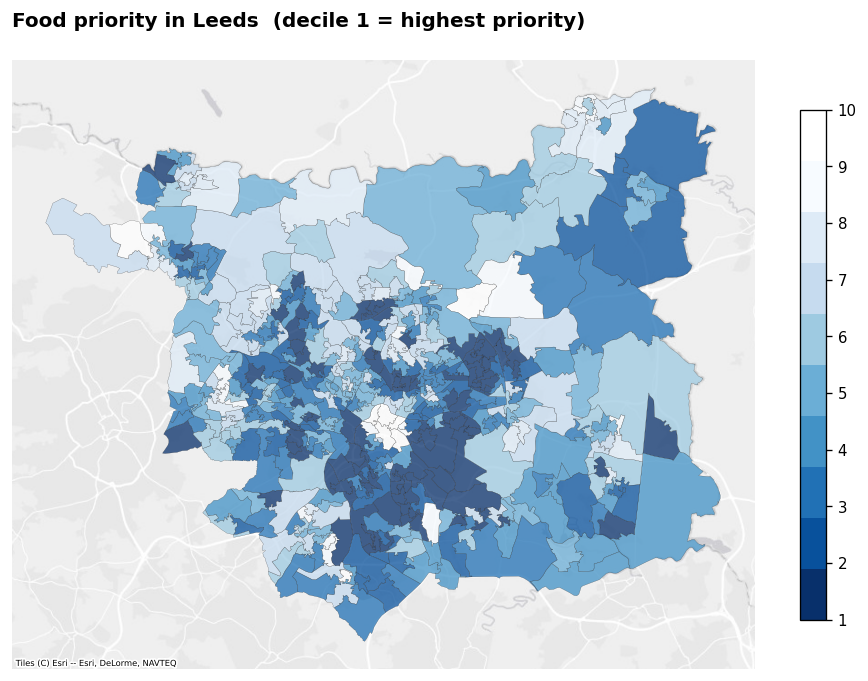

156 of 488 neighbourhoods are high food-priority (decile ≤ 2).


In [20]:
# ── B1 ── the first map ───────────────────────────────────────────────
show_map(area, "food_decile", f"Food priority in {AREA_NAME}  (decile 1 = highest priority)")

n_high = high_need(area["food_decile"]).sum()
print(f"{n_high} of {len(area)} neighbourhoods are high food-priority (decile ≤ {WORST}).")

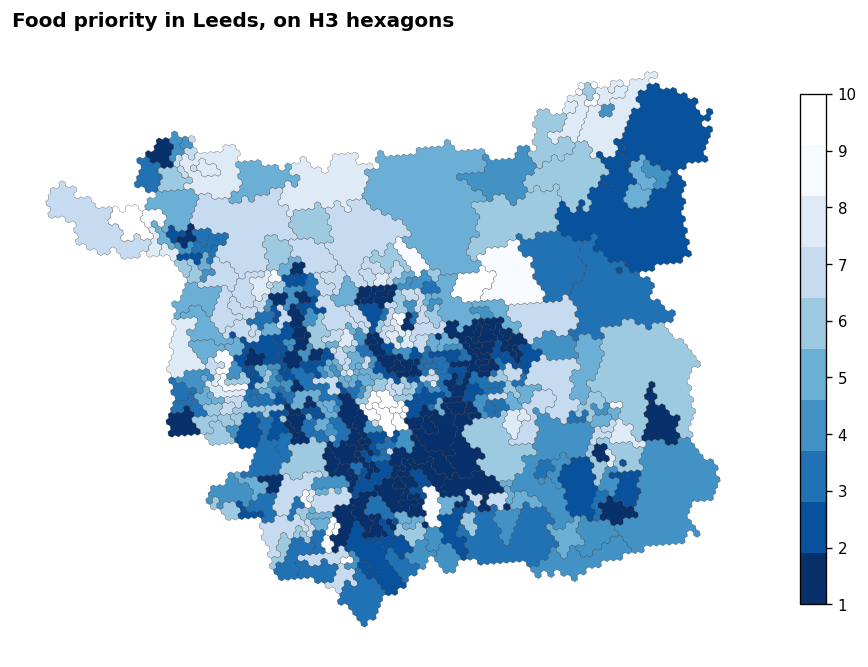

In [21]:
# ── B2 ── the same map, approximated onto H3 hexagons ─────────
# ✏️ CHANGE THIS: higher res = smaller hexes = finer detail (and slower)
# res 9 has about 175m edges
h3_resolution = 9
# ──────────────────────────────────────────

show_map_h3(area, "food_decile",
            f"Food priority in {AREA_NAME}, on H3 hexagons",
            res=h3_resolution)

---
# C · Do different problems hit the same places?

**What C1–C3 do:** measure how much the three indices agree, then show it two ways, a grid of
counts (C2) and a map (C3).

**Why:** if every index pointed at the same neighbourhoods you'd only need one. Whether they overlap
decides whether "just use deprivation" is good enough.

**How to read it:** correlation runs from −1 to +1. Near **+1** = the two rank places almost
identically; near **0** = unrelated. The percentages say, of the worst food-need areas, what share
are *also* worst on each other measure. **A low percentage is a finding, not a mistake**, it means
that problem lives somewhere else.

In [22]:
# ── C1 ── how much do the three indices agree? ────────────────────────
show_agreement_stats(area)

Spearman rank correlation (1.0 = identical ordering)



,food_decile,imd_decile,insulation_decile
food_decile,1.00,0.74,0.16
imd_decile,0.74,1.00,0.22
insulation_decile,0.16,0.22,1.00



156 neighbourhoods are high food-need. Of those:
  66% are also high deprivation
  21% are also high insulation need


**C2, the grid.** Each square counts neighbourhoods with that combination of two deciles. A bright
band along the diagonal means the two indices mostly agree; mass off the diagonal means they point
at different places.

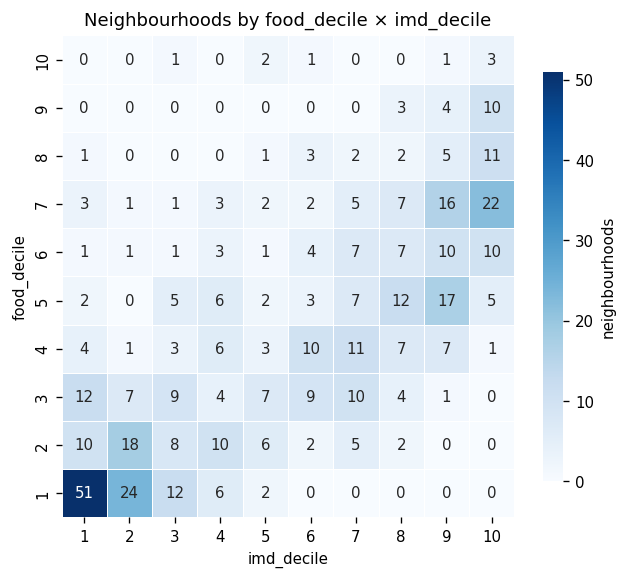

In [23]:
# ── C2 ── the agreement grid ──────────────────────────────────────────
# ✏️ CHANGE THESE to compare a different pair
var_1 = "food_decile"
var_2 = "imd_decile"        # try "insulation_decile"
# ──────────────────────────────────────────────

plot_agreement_heatmap(area, var_1, var_2)

**C3, the same two indices, on the ground.** The grid *counts*; a map shows *where*.
Teal = worst on `var_1` only · pink = worst on `var_2` only · **dark = worst on both** · pale = fine
on both. Where the colours split is where a food-specific index earns its place.

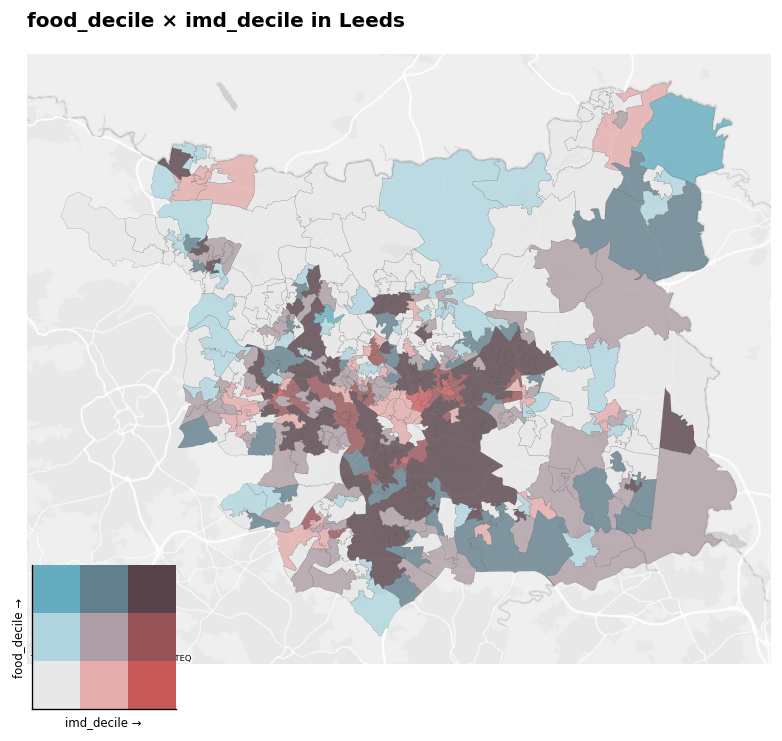

In [24]:
# ── C3 ── the same comparison as a map ────────────────────────────────
plot_bivariate_map(area, var_1, var_2)

<div style="background:#e8f4f8;padding:12px;border-left:4px solid #4a90a4">

### ✏️ Group task 1 - swap the comparison

The heatmap and bivariate map compare food priority with deprivation. Change **one variable** to compare
food priority with **insulation need** instead (use `insulation_decile`), re-run the cell, and eyeball it:
does insulation need track food priority as tightly as deprivation did? What would a council miss if it
only ever looked at deprivation?
</div>

---
# D · Where do the burdens stack up?  ← the thing to take away

**What D1 does:** for every neighbourhood, counts how many of the three problems, food priority,
deprivation, insulation need, it falls in the worst fifth for. That's a **0–3 "stacked burden"
score**. Then it lists the worst ten and maps them.

**Why:** a place with one problem is different from a place with three at once. Stacking finds where
a single intervention relieves the most pressure.

**How to read it:** **3** = worst fifth on *all three*. The **top-10 table** is the concrete output, 
real, named neighbourhoods you could walk into a meeting with. Change `WORST` in **S1** to see how
sensitive that list is to where you draw the line.

Leeds neighbourhoods by number of stacked burdens:


burden_count
0    245
1    114
2    106
3     23
Name: neighbourhoods, dtype: int64


Top 10 highest-need neighbourhoods in Leeds:


,name,district,food_decile,imd_decile,insulation_decile,burden_count
0,Leeds 086B,Leeds,1,1,1.0,3
1,Leeds 075C,Leeds,1,1,1.0,3
2,Leeds 067H,Leeds,1,1,1.0,3
3,Leeds 048B,Leeds,1,1,1.0,3
4,Leeds 086D,Leeds,1,1,1.0,3
5,Leeds 082A,Leeds,1,1,1.0,3
6,Leeds 048D,Leeds,1,1,1.0,3
7,Leeds 082D,Leeds,1,1,1.0,3
8,Leeds 075B,Leeds,1,1,1.0,3
9,Leeds 082C,Leeds,1,1,1.0,3


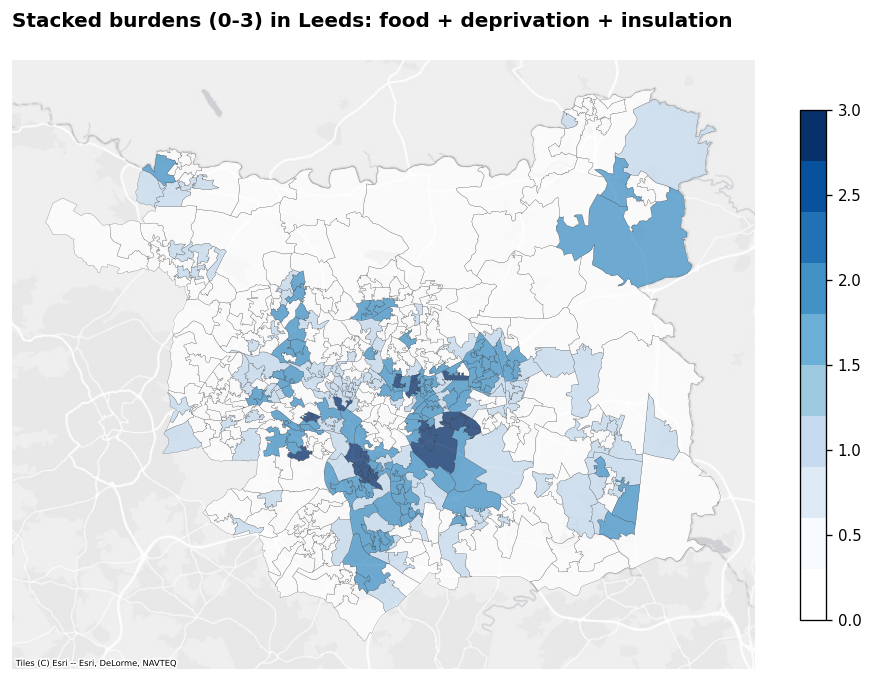

In [25]:
# ── D1 ── stack the burdens and pull out the short list ───────────────
area = add_burden_count(area)
top10 = show_top_neighbourhoods(area, n=10)

show_map(area, "burden_count",
         f"Stacked burdens (0-3) in {AREA_NAME}: food + deprivation + insulation",
         cmap=HASP_BLUES)

---
# E · Make it argue something: kepler.gl

**E1** writes `area_need.geojson` and downloads it. Then you style it in the browser, no code.

In [26]:
# ── E1 ── export for kepler.gl ────────────────────────────────────────
export_for_kepler(area)

wrote area_need.geojson and area_need.csv
(not on Colab, find the files in the folder on the left)


<div style="background:#f0f0f0;padding:14px;border-left:4px solid #666">

### ✏️ Group task 2 - build a map that argues for something (kepler)

Run the cell above, then open **kepler.gl/demo → Add Data** and drop in `area_need.geojson`
(it downloaded to your machine). Kepler builds the map on its own - now make it *say* something:

- **Colour** by `burden_count` (or `food_decile`) - Layer → Fill Colour
- **Colour scale → Quantize** - watch the story shift as you change the scale
- **3D**: turn on Height and extrude by `burden_count` - the hardest-hit areas rise as peaks
- **Filter** `food_decile` ≤ 2 - the map collapses to just where you'd act

Build **one** map you could put in front of a councillor, and be ready to say - in a single sentence -
what it argues for. Then **Share → Export Image** for your slide.
</div>

---
# F · Rent over time: a different shape of data

So far every dataset has been *one number per neighbourhood*. Rent data has a **time** dimension too,
which lets you ask how places change, not just how they compare.

**How to read it:** F2 is the national picture; F3 splits it by region. Watch the gap between regions
widen or narrow, that gap is the story, more than any single line.

In [27]:
# ── F1 ── load rent, with region labels attached ──────────────────────
rent = load_rent()
print(f"{len(rent):,} rows · {rent['closing_year'].min()}-{rent['closing_year'].max()}")
rent.head()

303,795 rows · 2016-2024


,lsoa_code,lsoa_name,closing_year,listing_count,median_rent,uq_rent,lq_rent,median_listing_views,percentage_detached,percentage_semidetached,...,WD25CD,WD25NM,LAD25CD,LAD25NM_x,PCON24CD,PCON24NM,LAD25NM_y,RGN25CD,RGN25NM,ObjectId
0,E01000001,City of London 001A,2016,112,475.0,553.0,420.0,222.0,0.0,0.0,...,E05009288,Aldersgate,E09000001,City of London,E14001172,Cities of London and Westminster,City of London,E12000007,London,204
1,E01000001,City of London 001A,2017,98,475.0,568.0,380.0,221.0,0.0,0.0,...,E05009288,Aldersgate,E09000001,City of London,E14001172,Cities of London and Westminster,City of London,E12000007,London,204
2,E01000001,City of London 001A,2018,98,460.0,550.0,371.0,210.0,0.0,0.0,...,E05009288,Aldersgate,E09000001,City of London,E14001172,Cities of London and Westminster,City of London,E12000007,London,204
3,E01000001,City of London 001A,2019,124,498.0,575.0,385.0,230.0,0.0,0.0,...,E05009288,Aldersgate,E09000001,City of London,E14001172,Cities of London and Westminster,City of London,E12000007,London,204
4,E01000001,City of London 001A,2020,152,488.0,560.0,389.0,331.0,0.0,0.0,...,E05009288,Aldersgate,E09000001,City of London,E14001172,Cities of London and Westminster,City of London,E12000007,London,204


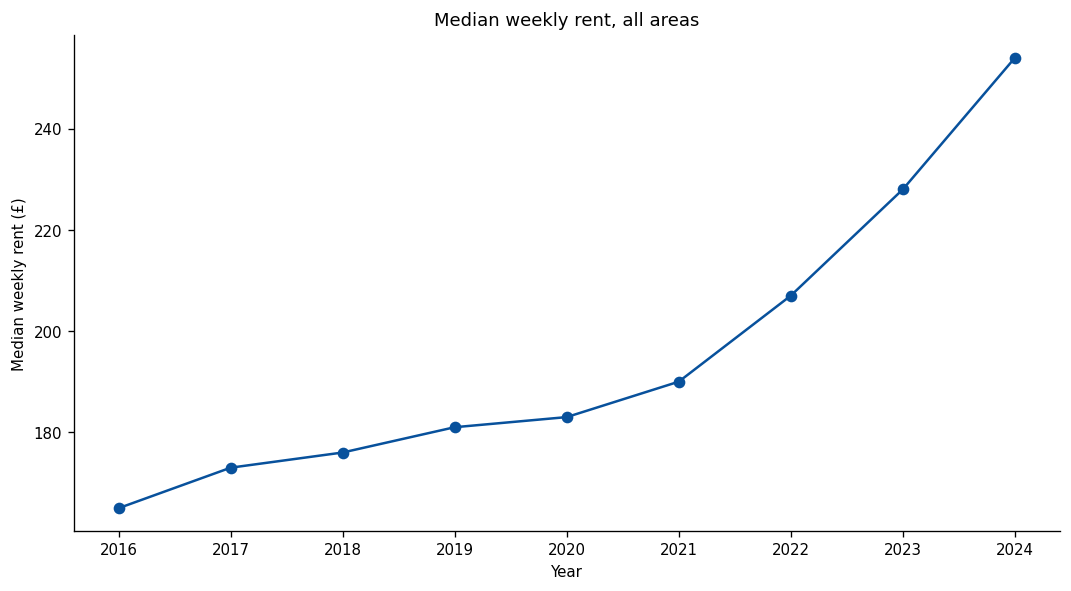

In [28]:
# ── F2 ── the national trend ──────────────────────────────────────────
plot_rent_trend(rent)

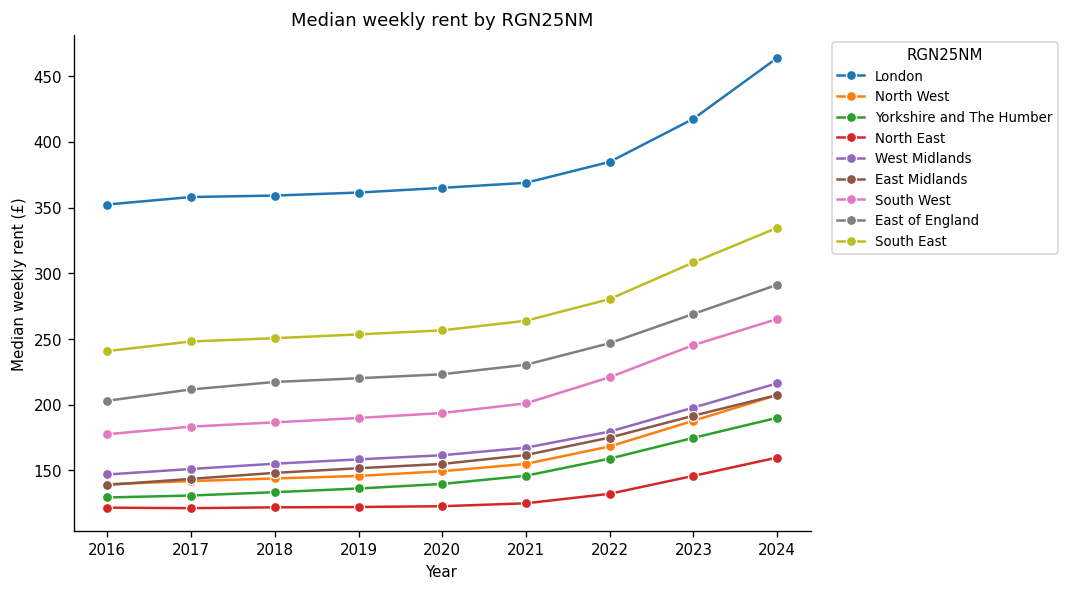

In [34]:
# ── F3 ── split by region ─────────────────────────────────────────────
# ✏️ CHANGE THIS to split a different way (e.g. "LAD25NM_x" for Local authorities)
split_by = "RGN25NM"
# ──────────────────────────────────────────────

plot_rent_trend(rent, by=split_by)

---
# H · Bring your own data

Everything above used data we prepared. This section is a **template for your own**.

### 1. Get a dataset

Browse the **HASP data portal, [data.hasp.ac.uk](https://data.hasp.ac.uk)**, and download any
**LSOA-level** CSV. Good candidates: house sale prices, access to green space, air quality, any of
the Priority Places indices.

*(Anything with one row per LSOA works, it doesn't have to be ours.)*

### 2. Upload it

Run **H1**. On Colab it opens a file picker. You can also drag the file into the folder pane on the
left and skip H1 entirely.

### 3. Map it

Tell **H2** which column holds the LSOA code and which holds the value you want to map. It joins to
the boundaries and hands back something `show_map()` can draw.

> **Heads up:** your file must use **2021 LSOA codes** (`E01xxxxxx`). If nothing matches, that's
> almost always why, older files use 2011 codes, which don't all line up.

In [35]:
# ── H1 ── point at your own data ──────────────────────────────────────
# ✏️ Two ways in. Leave as None and the rest of the notebook still runs fine.
MY_FILE = None

# (a) drag a CSV into the folder pane on the left, then put its name here:
# MY_FILE = "my_dataset.csv"

# (b) or uncomment this to open a file picker (Colab only):
# MY_FILE = upload_csv()
# ──────────────────────────────────────────────

print("MY_FILE =", MY_FILE)

MY_FILE = None


In [36]:
# ── H2 ── join it to the map and draw it ──────────────────────────────
# ✏️ TELL IT ABOUT YOUR FILE
CODE_COLUMN  = "lsoa21cd"      # the column holding LSOA codes (E01...)
VALUE_COLUMN = "your_value"    # the column you want to map
# ──────────────────────────────────────────────

if MY_FILE:
    mine = join_my_data(MY_FILE, CODE_COLUMN, VALUE_COLUMN)
    show_map(mine, "my_value", f"My dataset in {AREA_NAME}", cmap=HASP_BLUES)
else:
    print("No file yet, set MY_FILE in H1, then re-run this cell.")

No file yet, set MY_FILE in H1, then re-run this cell.


**Want the deciles treatment?** Once it's joined you can reuse everything above, for example:

```python
mine["my_decile"] = pd.qcut(mine["my_value"].rank(method="first"), 10, labels=range(10, 0, -1)).astype(int)
show_map(mine, "my_decile", "My dataset, in deciles")
```

Or compare it against food priority:

```python
both = area.merge(mine[["lsoa", "my_value"]], on="lsoa")
plot_agreement_heatmap(both.assign(my_decile=...), "food_decile", "my_decile")
```

---
## Where this goes next

In an afternoon you did what HASP does across every neighbourhood in the UK: pulled several open,
LSOA-level datasets together and turned them into a short, defensible list of places to act.

**Honest limits**, they decide whether you can trust any of it:

- "worst fifth" (decile ≤ 2) is a choice; move `WORST` in **S1** and the short list moves with it
- three equally-weighted burdens is a simplification: a real brief would weight and justify them
- indices can disagree on *direction* (we flipped insulation): always check before combining
- none of these numbers carry uncertainty, and a real analysis must

### Data sources & attribution

| Dataset | Source | Licence |
|---|---|---|
| Priority Places for Food Index v2.1 | HASP (orig. CDRC) | OGL v3.0 |
| English Indices of Deprivation 2025 | MHCLG | OGL v3.0 |
| Priority Places for Insulation Index | Which? / CDRC | OGL v3.0 |
| LSOA (Dec 2021) Boundaries | ONS Open Geography Portal | OGL v3.0 |
| Rental listings | Zoopla / WhenFresh via CDRC | Research licence |

> Source: Office for National Statistics licensed under the Open Government Licence v.3.0
>
> Contains OS data © Crown copyright and database right 2021

**Cite PPFI:** Pontin, F., Oldroyd, R., Baudains, P., Ennis, E., Newing, A., & Morris, M. A. (2024)
'Priority Places for Food Index' (Version 2.1). Data asset provided by the Healthy & Sustainable
Places Data Service (ES/Z504336/1); originally produced by the CDRC
(ES/L011840/1; ES/L011891/1). DOI:10.82147/003

---

**Talk to us, [hasp.ac.uk](https://hasp.ac.uk)**